In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [42]:
df = pd.read_csv("../../data/rolling_feature_engineered_tier_1_games.csv")

df.head()

,previous_10_game_team1_player1_average_kills,previous_10_game_team1_player1_average_deaths,previous_10_game_team1_player1_average_assists,previous_10_game_team1_player1_average_adr,previous_10_game_team1_player1_average_kast,previous_10_game_team1_player1_average_kddiff,previous_10_game_team1_player2_average_kills,previous_10_game_team1_player2_average_deaths,previous_10_game_team1_player2_average_assists,previous_10_game_team1_player2_average_adr,...,team1_player1_id,team1_player2_id,team1_player3_id,team1_player4_id,team1_player5_id,team2_player1_id,team2_player2_id,team2_player3_id,team2_player4_id,team2_player5_id
0,16.000000,15.000000,4.000000,75.000000,70.000000,1.000000,16.000000,15.000000,4.000000,75.000000,...,553.0,39.0,612.0,163.0,457.0,739.0,1443.0,65.0,2049.0,209.0
1,12.000000,17.000000,4.000000,59.100000,62.500000,-5.000000,13.000000,11.000000,2.000000,52.600000,...,553.0,39.0,612.0,163.0,457.0,739.0,1443.0,65.0,2049.0,209.0
2,13.500000,16.500000,4.500000,66.250000,71.750000,-3.000000,18.500000,11.000000,4.000000,82.550000,...,553.0,39.0,612.0,163.0,457.0,739.0,1443.0,65.0,2049.0,209.0
3,14.612903,14.645161,4.258065,69.832258,71.535484,-0.032258,14.612903,14.645161,4.258065,69.832258,...,3202.0,1420.0,3168.0,607.0,3032.0,3836.0,1886.0,2588.0,1778.0,4567.0
4,13.000000,5.000000,1.000000,81.300000,86.700000,8.000000,11.000000,6.000000,4.000000,72.100000,...,3202.0,1420.0,3168.0,607.0,3032.0,3836.0,1886.0,2588.0,1778.0,4567.0


In [43]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

##we need sort time, since we want use previous games to predict new games.

stats = ["kills", "deaths", "assists", "adr", "kast", "kddiff"]

for stat in stats:
    team1_cols = [
        f"previous_10_game_team1_player{i}_average_{stat}"
        for i in range(1, 6)
    ]
    
    team2_cols = [
        f"previous_10_game_team2_player{i}_average_{stat}"
        for i in range(1, 6)
    ]
    
    df[f"team1_avg_{stat}"] = df[team1_cols].mean(axis=1)
    df[f"team2_avg_{stat}"] = df[team2_cols].mean(axis=1)
    
    df[f"{stat}_diff"] = df[f"team1_avg_{stat}"] - df[f"team2_avg_{stat}"]
    
df.head()

,previous_10_game_team1_player1_average_kills,previous_10_game_team1_player1_average_deaths,previous_10_game_team1_player1_average_assists,previous_10_game_team1_player1_average_adr,previous_10_game_team1_player1_average_kast,previous_10_game_team1_player1_average_kddiff,previous_10_game_team1_player2_average_kills,previous_10_game_team1_player2_average_deaths,previous_10_game_team1_player2_average_assists,previous_10_game_team1_player2_average_adr,...,assists_diff,team1_avg_adr,team2_avg_adr,adr_diff,team1_avg_kast,team2_avg_kast,kast_diff,team1_avg_kddiff,team2_avg_kddiff,kddiff_diff
0,16.000000,15.000000,4.000000,75.000000,70.000000,1.000000,16.000000,15.000000,4.000000,75.000000,...,0.0,75.000000,75.000000,0.00,70.000000,70.000000,0.00,1.000000,1.000000,0.0
1,12.000000,17.000000,4.000000,59.100000,62.500000,-5.000000,13.000000,11.000000,2.000000,52.600000,...,-3.2,68.160000,67.640000,0.52,68.320000,66.640000,1.68,0.600000,-0.600000,1.2
2,13.500000,16.500000,4.500000,66.250000,71.750000,-3.000000,18.500000,11.000000,4.000000,82.550000,...,-0.8,70.120000,67.010000,3.11,72.260000,63.790000,8.47,1.500000,-1.600000,3.1
3,14.612903,14.645161,4.258065,69.832258,71.535484,-0.032258,14.612903,14.645161,4.258065,69.832258,...,0.0,69.832258,69.832258,0.00,71.535484,71.535484,0.00,-0.032258,-0.032258,0.0
4,13.000000,5.000000,1.000000,81.300000,86.700000,8.000000,11.000000,6.000000,4.000000,72.100000,...,3.0,92.420000,45.620000,46.80,88.000000,40.000000,48.00,9.000000,-9.000000,18.0


In [44]:
df["map_score_diff"] = (
    df["team1_previous_10_average_map_score"]
    - df["team2_previous_10_average_map_score"]
)

feature_cols = [
    "kills_diff",
    "deaths_diff",
    "assists_diff",
    "adr_diff",
    "kast_diff",
    "kddiff_diff",
    "map_score_diff",
    "bestOf"
]

X = df[feature_cols]
y = df["team1_win"]

In [45]:
data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[feature_cols]
y = data["team1_win"]

In [46]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [47]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
baseline = y_test.value_counts(normalize=True).max()

print("Baseline Accuracy:", baseline)

Baseline Accuracy: 0.5586642599277978


In [49]:
results = []

for k in range(1, 101):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        "k": k,
        "test_accuracy": acc
    })

results_df = pd.DataFrame(results)

results_df.head()

,k,test_accuracy
0,1,0.497292
1,2,0.465704
2,3,0.490072
3,4,0.471119
4,5,0.515343


In [50]:
best_row = results_df.loc[results_df["test_accuracy"].idxmax()]

best_k = int(best_row["k"])
best_acc = best_row["test_accuracy"]

print("Best k:", best_k)
print("Best KNN Test Accuracy:", best_acc)
print("Baseline Accuracy:", baseline)

Best k: 76
Best KNN Test Accuracy: 0.5694945848375451
Baseline Accuracy: 0.5586642599277978


In [51]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train_scaled, y_train)

y_pred_best = best_knn.predict(X_test_scaled)

print("Best KNN Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("Baseline Accuracy:", baseline)

Best KNN Test Accuracy: 0.5694945848375451
Baseline Accuracy: 0.5586642599277978


In [52]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Confusion Matrix:
[[163 326]
 [151 468]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.33      0.41       489
           1       0.59      0.76      0.66       619

    accuracy                           0.57      1108
   macro avg       0.55      0.54      0.53      1108
weighted avg       0.56      0.57      0.55      1108



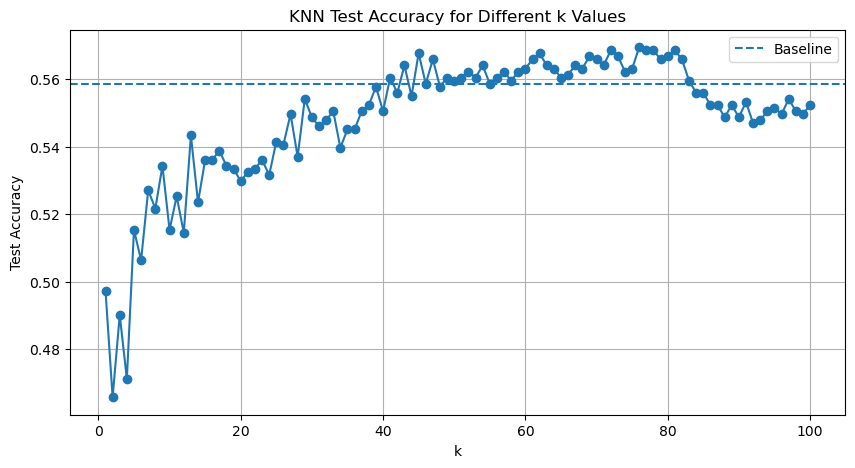

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(results_df["k"], results_df["test_accuracy"], marker="o")
plt.axhline(y=baseline, linestyle="--", label="Baseline")

plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("KNN Test Accuracy for Different k Values")
plt.legend()
plt.grid(True)
plt.show()